# UJIndoorLoc: Data Cleaning & Preprocessing
Replication of *Li, Wang & Wu – Indoor Positioning System Using Wifi Fingerprint*.

**Paper setup mirrored here**
- 3 buildings modelled **separately**, target = `FLOOR`
- PCA to **5 / 50 / 200** components
- Random subsamples of **100, 200, 500, 1000, 2000, 5000** rows
- 10-fold CV, 5 repeated rounds averaged (done in the modelling notebook)

**Outputs of this notebook:** a cleaned dataframe, per-building `(X, y)` sets, and helper functions (`subsample`, `pca_features`) that the modelling notebooks can reuse.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DATA_PATH = "trainingData.csv"   # change if the file lives elsewhere
NOT_DETECTED = 100               # UJIndoorLoc sentinel: "AP not heard"
FILL_VALUE = -105                # just below the weakest real reading (-104 dBm)
SAMPLE_SIZES = [100, 200, 500, 1000, 2000, 5000]
PCA_SIZES = [5, 50, 200]
SEED = 42

## 2. Load raw data

In [2]:
raw = pd.read_csv(DATA_PATH)
WAPS = [c for c in raw.columns if c.startswith("WAP")]
META = [c for c in raw.columns if not c.startswith("WAP")]
print("shape:", raw.shape)
print("WAP columns:", len(WAPS), "| metadata columns:", META)
raw[META].head()

shape: (19937, 529)
WAP columns: 520 | metadata columns: ['LONGITUDE', 'LATITUDE', 'FLOOR', 'BUILDINGID', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']


,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


## 3. Audit the raw data

In [3]:
vals = raw[WAPS].values
detected = vals[vals != NOT_DETECTED]

print("NaNs:                         ", raw.isna().sum().sum())
print("Cells == 100 (not detected):  %.2f%%" % (100 * (vals == NOT_DETECTED).mean()))
print("Real RSSI range:              %d to %d dBm" % (detected.min(), detected.max()))
print("Rows with no AP detected:     ", (raw[WAPS] == NOT_DETECTED).all(axis=1).sum())
print("APs never detected:           ", (raw[WAPS] == NOT_DETECTED).all(axis=0).sum())
print("Exact duplicate rows:         ", raw.duplicated().sum())
print("Duplicate fingerprints only:  ", raw[WAPS].duplicated().sum())
print()
print("Samples per building / floor:")
raw.groupby(["BUILDINGID", "FLOOR"]).size().unstack(fill_value=0)

NaNs:                          0
Cells == 100 (not detected):  96.54%
Real RSSI range:              -104 to 0 dBm
Rows with no AP detected:      76
APs never detected:            55
Exact duplicate rows:          637
Duplicate fingerprints only:   852

Samples per building / floor:


FLOOR,0,1,2,3,4
BUILDINGID,,,,,
0,1059,1356,1443,1391,0
1,1368,1484,1396,948,0
2,1942,2162,1577,2709,1102


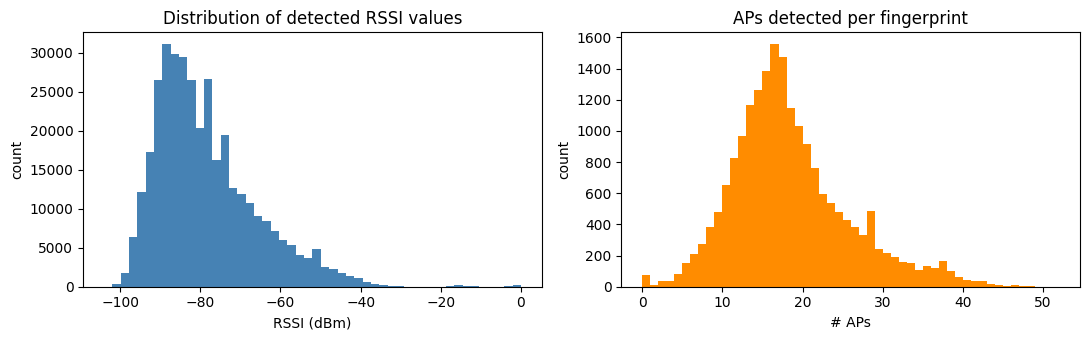

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(detected, bins=50, color="steelblue")
ax[0].set(title="Distribution of detected RSSI values", xlabel="RSSI (dBm)", ylabel="count")
n_det = (raw[WAPS] != NOT_DETECTED).sum(axis=1)
ax[1].hist(n_det, bins=range(0, n_det.max() + 2), color="darkorange")
ax[1].set(title="APs detected per fingerprint", xlabel="# APs", ylabel="count")
plt.tight_layout(); plt.show()

**Findings:** 96.5% of cells are the `100` sentinel (an AP that wasn't heard, *not* a strong signal), so it must be recoded before any distance-based model (kNN/SVM/PCA) sees it. The data also contains empty fingerprints, never-seen APs and duplicate rows.

## 4. Clean

| Step | Why |
|---|---|
| `100` → NaN | sentinel is not a real reading |
| drop rows with no AP detected | carry no information |
| drop exact duplicate rows | with kNN (k=1) duplicates leak across CV folds and inflate accuracy |
| drop APs never detected | constant columns |
| check conflicting labels | same fingerprint, different floor/building |
| NaN → `-105` | keeps "weaker than anything real" ordering, which is meaningful for distances |

In [5]:
def load_clean(df_raw, fill_value=FILL_VALUE, drop_duplicates=True):
    """Global cleaning. Set fill_value=None to keep NaN (for models that handle missing values).
    Set drop_duplicates=False for a strictly 'paper-faithful' run."""
    df = df_raw.copy()
    waps = [c for c in df.columns if c.startswith("WAP")]
    log = {"raw_rows": len(df), "raw_waps": len(waps)}

    df[waps] = df[waps].replace(NOT_DETECTED, np.nan)

    empty = df[waps].isna().all(axis=1)
    log["rows_no_ap_detected"] = int(empty.sum())
    df = df[~empty]

    if drop_duplicates:
        n = len(df)
        df = df.drop_duplicates()
        log["exact_duplicates_dropped"] = n - len(df)

    dead = [c for c in waps if df[c].isna().all()]
    log["waps_never_detected"] = len(dead)
    df = df.drop(columns=dead)
    waps = [c for c in waps if c not in dead]

    key = pd.util.hash_pandas_object(df[waps].fillna(NOT_DETECTED), index=False)
    conf = pd.DataFrame({"k": key.values, "b": df.BUILDINGID.values,
                         "f": df.FLOOR.values}).groupby("k")[["b", "f"]].nunique()
    log["conflicting_label_fingerprints"] = int((conf > 1).any(axis=1).sum())

    if fill_value is not None:
        df[waps] = df[waps].fillna(fill_value)

    log["clean_rows"], log["clean_waps"] = len(df), len(waps)
    out = df.reset_index(drop=True)
    return out, log

df, log = load_clean(raw)
pd.Series(log, name="cleaning log").to_frame()

,cleaning log
raw_rows,19937
raw_waps,520
rows_no_ap_detected,76
exact_duplicates_dropped,634
waps_never_detected,55
conflicting_label_fingerprints,0
clean_rows,19227
clean_waps,465


## 5. Per-building datasets
Each building is modelled separately (as in the paper). APs never heard in a building are dropped for that building.

In [6]:
def building_data(df, building, target="FLOOR"):
    sub = df[df["BUILDINGID"] == building]
    waps = [c for c in sub.columns if c.startswith("WAP")]
    X = sub[waps]
    keep = X.columns[(X != FILL_VALUE).any(axis=0)] if not X.isna().any().any() \
           else X.columns[X.notna().any(axis=0)]
    return X[keep].reset_index(drop=True), sub[target].reset_index(drop=True)

data = {b: building_data(df, b) for b in sorted(df.BUILDINGID.unique())}
for b, (X, y) in data.items():
    print(f"Building {b}: X={X.shape}, floors={y.value_counts().sort_index().to_dict()}")

Building 0: X=(5245, 200), floors={0: 1056, 1: 1356, 2: 1443, 3: 1390}
Building 1: X=(4904, 207), floors={0: 1333, 1: 1266, 2: 1396, 3: 909}
Building 2: X=(9078, 203), floors={0: 1906, 1: 2161, 2: 1576, 3: 2708, 4: 727}


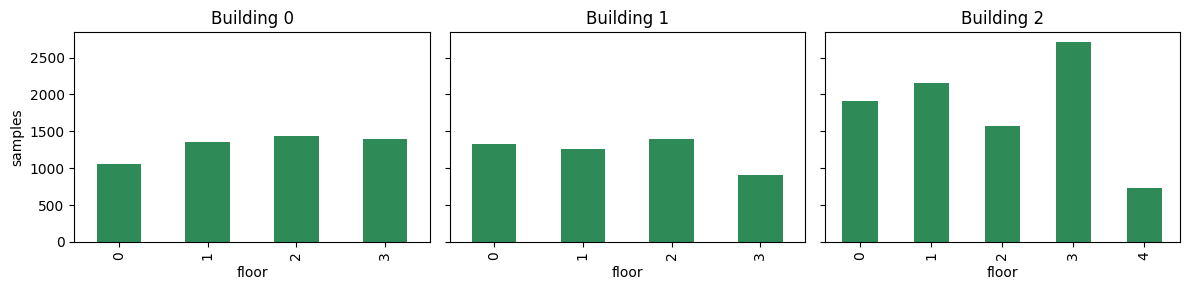

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for a, (b, (X, y)) in zip(ax, data.items()):
    y.value_counts().sort_index().plot.bar(ax=a, color="seagreen")
    a.set(title=f"Building {b}", xlabel="floor")
ax[0].set_ylabel("samples"); plt.tight_layout(); plt.show()

**Notes for the write-up**
- Building 1 has fewer than 5000 rows after cleaning, so the 5000-sample setting equals "use everything" there.
- After per-building AP filtering only ~200 features remain, so **200 PCA components is essentially a rotation, not a reduction**.
- Building 2 is the only one with a floor 4, and it is the smallest class.

## 6. Helpers for the modelling notebooks
**Subsampling** is plain random, as in the paper (`stratify=True` is available if a class becomes too small for 10-fold CV).

**PCA** is fit on **training data only**. The paper appears to fit PCA once on all data before CV, which leaks a little; call `pca_features` inside each fold to avoid that. For a faithful replication, also run the "PCA on everything" variant and report both.

In [8]:
def subsample(X, y, n, seed=SEED, stratify=False):
    if n >= len(X):
        return X.copy(), y.copy()
    rng = np.random.RandomState(seed)
    if stratify:
        idx = np.concatenate([
            rng.choice(np.where(y.values == c)[0],
                       max(2, round(n * (y == c).mean())), replace=False)
            for c in np.unique(y)])
    else:
        idx = rng.choice(len(X), n, replace=False)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


def pca_features(X_train, X_test=None, n_components=50, scale=True):
    """Fit scaler+PCA on train only; transform test with the same fit."""
    n_components = min(n_components, X_train.shape[0], X_train.shape[1])
    sc = StandardScaler() if scale else None
    Xtr = sc.fit_transform(X_train) if sc else X_train.values
    pca = PCA(n_components=n_components, random_state=0).fit(Xtr)
    Ztr = pca.transform(Xtr)
    if X_test is None:
        return Ztr, pca
    Xte = sc.transform(X_test) if sc else X_test.values
    return Ztr, pca.transform(Xte), pca

## 7. PCA energy plot (cf. paper Fig. 2) and explained variance

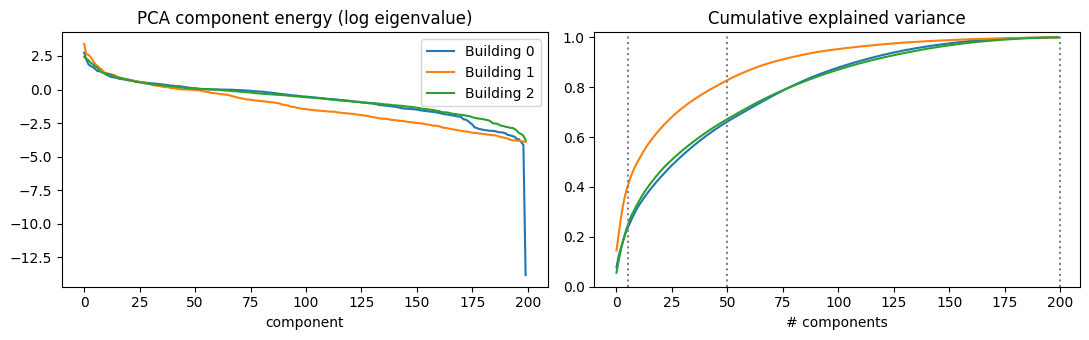

Building 0: variance kept by 5 / 50 / 200 PCs = 0.21 / 0.66 / 1.00
Building 1: variance kept by 5 / 50 / 200 PCs = 0.37 / 0.82 / 1.00
Building 2: variance kept by 5 / 50 / 200 PCs = 0.22 / 0.67 / 1.00


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for b, (X, y) in data.items():
    _, pca = pca_features(X, n_components=min(200, X.shape[1]))
    ax[0].plot(np.log(np.maximum(pca.explained_variance_, 1e-6)), label=f"Building {b}")
    ax[1].plot(np.cumsum(pca.explained_variance_ratio_), label=f"Building {b}")
ax[0].set(title="PCA component energy (log eigenvalue)", xlabel="component")
ax[1].set(title="Cumulative explained variance", xlabel="# components", ylim=(0, 1.02))
for k in PCA_SIZES: ax[1].axvline(k, ls=":", c="gray")
ax[0].legend(); plt.tight_layout(); plt.show()

for b, (X, y) in data.items():
    _, pca = pca_features(X, n_components=min(200, X.shape[1]))
    cum = np.cumsum(pca.explained_variance_ratio_)
    print(f"Building {b}: variance kept by 5 / 50 / 200 PCs = "
          + " / ".join(f"{cum[min(k, len(cum)) - 1]:.2f}" for k in PCA_SIZES))

## 8. Sanity check
Quick holdout kNN (k=1) on each building. This is **not** the paper's CV experiment; it only confirms the preprocessing is sound.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

for b, (X, y) in data.items():
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    Ztr, Zte, _ = pca_features(Xtr, Xte, n_components=50)
    acc = KNeighborsClassifier(n_neighbors=1).fit(Ztr, ytr).score(Zte, yte)
    print(f"Building {b}: holdout floor accuracy (kNN k=1, 50 PCs) = {acc:.3f}")

Building 0: holdout floor accuracy (kNN k=1, 50 PCs) = 0.986
Building 1: holdout floor accuracy (kNN k=1, 50 PCs) = 0.995
Building 2: holdout floor accuracy (kNN k=1, 50 PCs) = 0.992


## 9. Save cleaned data (optional)

In [11]:
import os
os.makedirs("cleaned", exist_ok=True)
for b, (X, y) in data.items():
    pd.concat([X, y], axis=1).to_csv(f"cleaned/building{b}_floor.csv", index=False)
print(os.listdir("cleaned"))

['building0_floor.csv', 'building1_floor.csv', 'building2_floor.csv']
